In [73]:
#importing all the required libraries for data modelling
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import shap

In [74]:
#loading the preprocessed data
data = pd.read_csv("Data/Sample_Data/sample_data.csv")

In [75]:
#defining features and target variable
X = data.drop(columns=['Label', 'BinaryLabel'])
y = data['BinaryLabel']

In [76]:
#splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#scaling the features using StandardScaler for Logistic Regression and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
# Logistic Regression Model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

In [78]:
print("Results from M1: Logisitic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1-score:", f1_score(y_test, lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Results from M1: Logisitic Regression
Accuracy: 0.85358
Precision: 0.9520789648647267
Recall: 0.74464
F1-score: 0.8356788543981326
Confusion Matrix:
 [[24063   937]
 [ 6384 18616]]
              precision    recall  f1-score   support

           0       0.79      0.96      0.87     25000
           1       0.95      0.74      0.84     25000

    accuracy                           0.85     50000
   macro avg       0.87      0.85      0.85     50000
weighted avg       0.87      0.85      0.85     50000



In [79]:
# Cross-validation for Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [80]:
# Random Forest Model
# Using GridSearchCV to find the best hyperparameters for Random Forest
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Define a smaller hyperparameter grid for tuning to reduce execution time
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Performing grid search
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Training the model with grid search
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)

rf_model = grid_search.best_estimator_
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 score: 0.9953571293789129


In [81]:
print("Results from M2: Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Results from M2: Random Forest
Accuracy: 0.99526
Precision: 0.9947256962480521
Recall: 0.9958
F1-score: 0.995262558218562
Confusion Matrix:
 [[24868   132]
 [  105 24895]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     25000
           1       0.99      1.00      1.00     25000

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



In [82]:
# Cross-validation for Random Forest
rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Random Forest CV Scores:", rf_cv_scores)
print("Average RF CV F1-score:", rf_cv_scores.mean())

Random Forest CV Scores: [0.99560018 0.99554045 0.99588214 0.99552215 0.99544219]
Average RF CV F1-score: 0.9955974200706159


In [83]:
# SVM Model (using LinearSVC for better performance on large datasets)
svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

In [84]:
print("Results from M3: SVM (LinearSVC)")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1-score:", f1_score(y_test, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

Results from M3: SVM (LinearSVC)
Accuracy: 0.85362
Precision: 0.9548284200236662
Recall: 0.74236
F1-score: 0.8352949118977429
Confusion Matrix:
 [[24122   878]
 [ 6441 18559]]
              precision    recall  f1-score   support

           0       0.79      0.96      0.87     25000
           1       0.95      0.74      0.84     25000

    accuracy                           0.85     50000
   macro avg       0.87      0.85      0.85     50000
weighted avg       0.87      0.85      0.85     50000



In [85]:
# Cross-validation for SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='linear', class_weight='balanced', random_state=42))
])

svm_cv_scores = cross_val_score(
    svm_pipeline,
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [86]:
# SVM Scores for ROC curve (using decision function for better performance)
svm_scores = svm_model.decision_function(X_test_scaled)

In [87]:
# Evaluating and comparing model performance
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred)
    ],
    'F1-score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, svm_scores)
    ]
})

print(results)

                 Model  Accuracy  Precision   Recall  F1-score   ROC-AUC
0  Logistic Regression   0.85358   0.952079  0.74464  0.835679  0.958172
1        Random Forest   0.99526   0.994726  0.99580  0.995263  0.999854
2                  SVM   0.85362   0.954828  0.74236  0.835295  0.957898


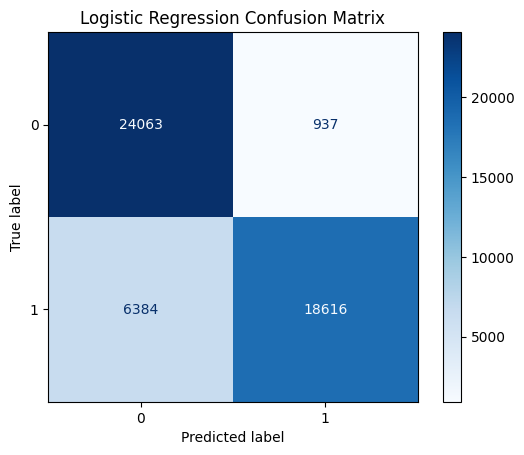

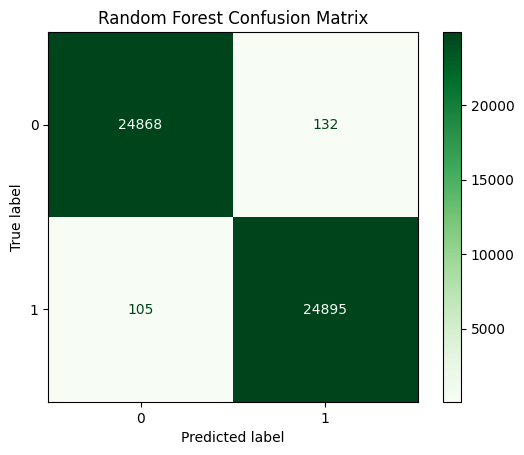

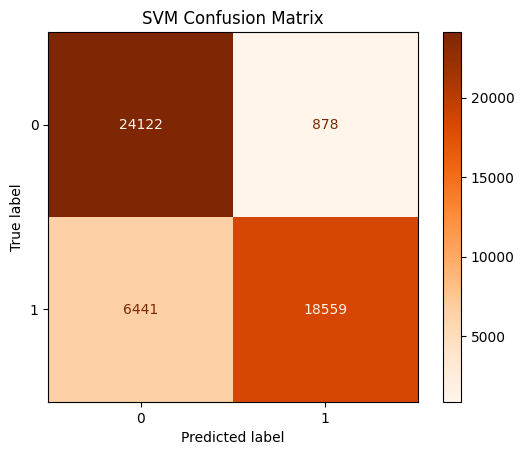

In [88]:
import matplotlib.pyplot as plt

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap='Blues'
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap='Greens'
)
plt.title("Random Forest Confusion Matrix")
plt.show()


# SVM Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap='Oranges'
)
plt.title("SVM Confusion Matrix")
plt.show()

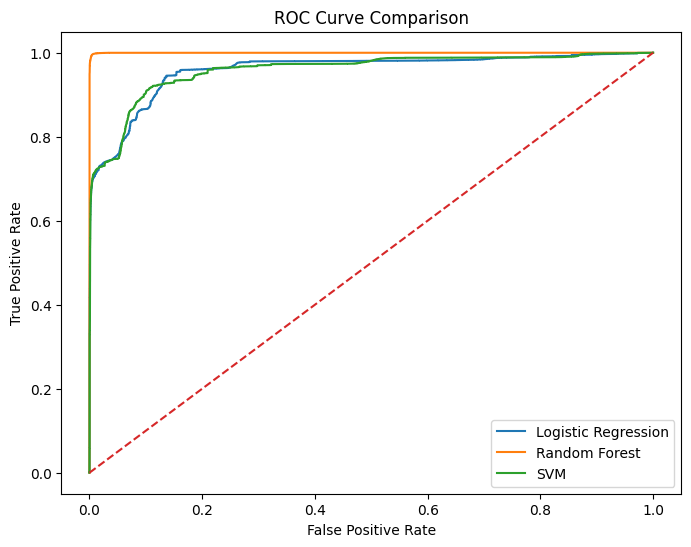

In [89]:
# Plotting ROC curves for all models

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

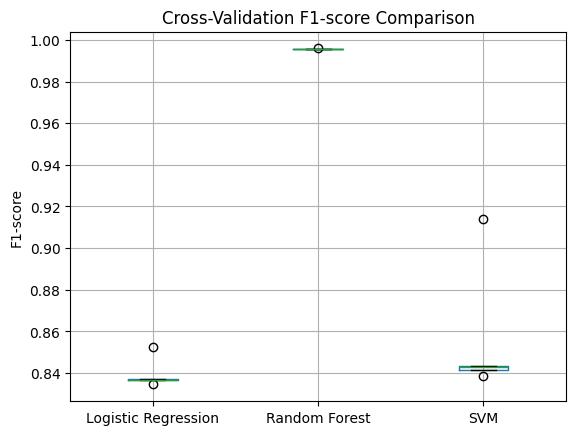

In [90]:
# Visualize cross-validation results for all models
cv_results = pd.DataFrame({
    'Logistic Regression': lr_cv_scores,
    'Random Forest': rf_cv_scores,
    'SVM': svm_cv_scores
})

cv_results.boxplot()

plt.title("Cross-Validation F1-score Comparison")
plt.ylabel("F1-score")
plt.show()

In [91]:
# Feature importance for Logistic Regression
lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

lr_importance = lr_importance.sort_values(by='Coefficient', ascending=False)

print(lr_importance.head(10))

                        Feature  Coefficient
14            Packet Length Std    13.103293
11                 Flow IAT Max     6.893769
13           Packet Length Mean     6.440798
1             Total Fwd Packets     4.091291
9                 Flow IAT Mean     2.198458
3   Total Length of Fwd Packets     1.372231
8                Flow Packets/s    -0.028604
7                  Flow Bytes/s    -0.701833
12                 Flow IAT Min    -1.861294
0                 Flow Duration    -2.555985


In [92]:
# Feature importance for Random Forest using permutation importance
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=5,
    random_state=42
)

perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

perm_importance.head(10)

,Feature,Importance
14,Packet Length Std,0.065157
6,Bwd Packet Length Mean,0.014069
1,Total Fwd Packets,0.008019
2,Total Backward Packets,0.007344
12,Flow IAT Min,0.003516
4,Total Length of Bwd Packets,0.003232
10,Flow IAT Std,0.003073
9,Flow IAT Mean,0.002780
11,Flow IAT Max,0.002212
0,Flow Duration,0.002051


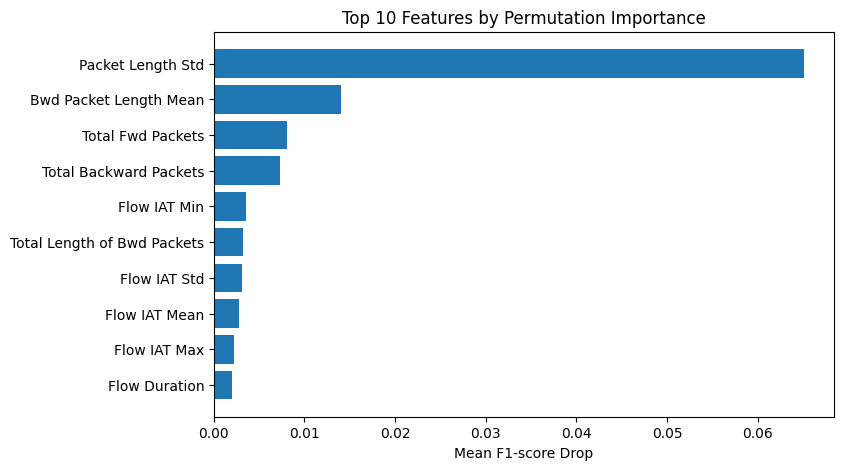

In [93]:
# Visualize the top 10 important features from permutation importance
top_perm = perm_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_perm['Feature'], top_perm['Importance'])
plt.xlabel("Mean F1-score Drop")
plt.title("Top 10 Features by Permutation Importance")
plt.gca().invert_yaxis()
plt.show()

Sample shape: (200, 16)
SHAP shape: (200, 16, 2)


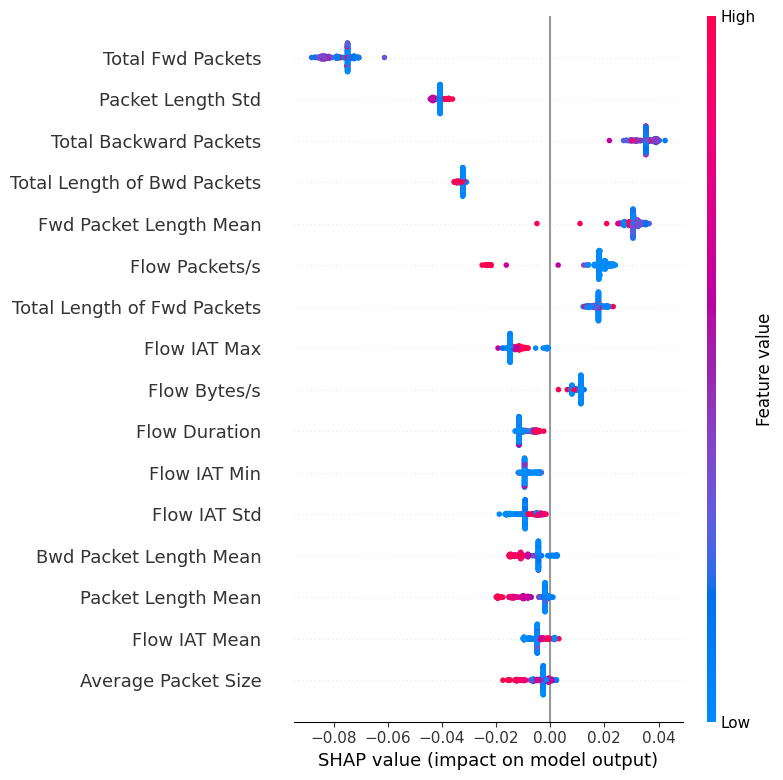

In [94]:
# SHAP values for Random Forest (using a smaller sample for efficiency)

sample = X_test_scaled[:200]
sample_df = pd.DataFrame(sample, columns=X.columns)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(sample_df)
print("Sample shape:", sample_df.shape)

# Check the shape of SHAP values to ensure they match the expected dimensions
if isinstance(shap_values, list):
    print("SHAP shape:", shap_values[1].shape)
    shap.summary_plot(shap_values[1], sample_df)
else:
    print("SHAP shape:", shap_values.shape)
    # Visualize SHAP values for binary classification 
    if len(shap_values.shape) == 3:
        shap.summary_plot(shap_values[:, :, 1], sample_df)
    else:
        shap.summary_plot(shap_values, sample_df)
        